In [150]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy
from sklearn.model_selection import KFold
from scipy.stats import t

phot_data = pd.read_csv("string_phot_rat_data.csv")
data = phot_data.drop(columns=['percentage_x', 'x_reach_centered', 'y_reach_centered', 'rat'])
data = data.dropna()

In [151]:
def linear_regression_gradient_descent(X, y):
    if len(X.shape) > 1:
        n_samples, n_features = X.shape
        weights = numpy.zeros(n_features)
    else:
        n_samples = X.size
        n_features = 1
        weights = 0
    # implement gradient descent
    # set initial weights and biases
    bias = 1
    learning_rate = 0.001
    epochs = 10000

    # fit the model
    for epoch in range(epochs):
        # calculate predicted y
        y_predicted = numpy.dot(X, weights) + bias
        # get the error for weights and bias
        diff_w = (1/n_samples) * numpy.dot(X.T, (y_predicted - y))
        diff_b = (1/n_samples) * numpy.sum(y_predicted - y)  

        # update weights and biases
        weights -= learning_rate*diff_w
        bias -= learning_rate*diff_b
    return weights, bias

In [170]:
def calculate_RSE(y_pred, y, n_sample, n_params):
    rss = numpy.sum((y_pred - y)**2)
    rse = numpy.sqrt(rss/(n_sample-n_params-1))
    return rse

def calculate_SE(x, rse):
    se = rse/numpy.sqrt(numpy.sum((x-numpy.mean(x))**2))
    return se

def calculate_R2(y, y_pred):
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    RSS = numpy.sum(numpy.square(y - y_pred))
    R2 = 1 - (RSS/TSS)
    return R2

def calculate_F(y, y_pred, n_features, n_samples):
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    # compute the residual sum of squares
    RSS = numpy.sum(numpy.square(y-y_pred))
    F = ((TSS-RSS)/n_features)/((RSS)/(n_samples - n_features - 1))
    return F

def calculate_tstat(x, rse, B):
    se = calculate_SE(x, rse)
    tstat = B/se
    return tstat

In [153]:
def k_fold_cross_val(X, y, n_samples, n_params):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rses = []
    for trainIX, testIX in kf.split(y):
        train_X, test_X = X[trainIX], X[testIX]
        train_y, test_y = y[trainIX], y[testIX]
        weight, bias = linear_regression_gradient_descent(train_X, train_y)
        y_pred = numpy.dot(test_X, weight) + bias
        rse = calculate_RSE(y_pred, test_y, len(test_y), n_params)
        rses.append(rse)
    rse =  numpy.mean(rses)
    return rse       

In [154]:
def simple_reg_for_each_parameter(X_df, y):    
    simple_reg_dict = {}
    # avoids the rat classifications
    for param in X_df.columns:
        X = X_df[param].to_numpy()
        rse = k_fold_cross_val(X, y, X.size, 1)
        weight, bias = linear_regression_gradient_descent(X, y)
        tstat = calculate_tstat(X, rse, weight)
        p_val = t.sf(abs(tstat), y.size - 2) * 2
        simple_reg_dict[param] = [bias, weight, rse, tstat, p_val]
        plt.figure()
        plt.scatter(X_df[param], y)
        plt.axline(xy1=(0,bias), slope=weight)
        plt.xlabel(param)
    
    return simple_reg_dict

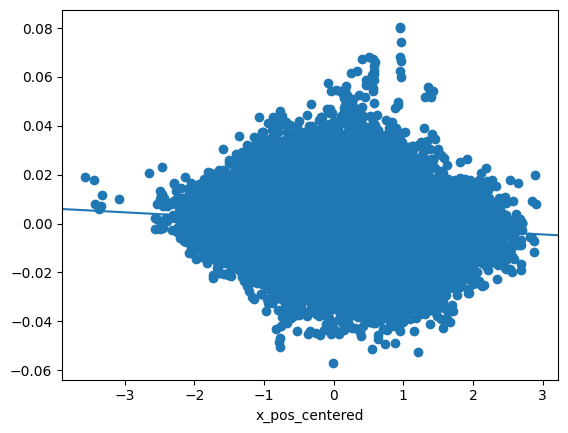

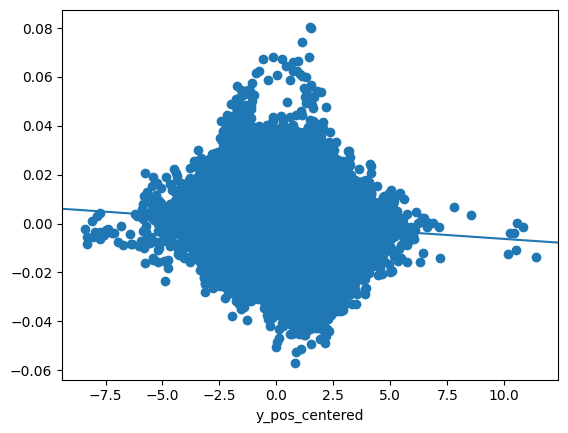

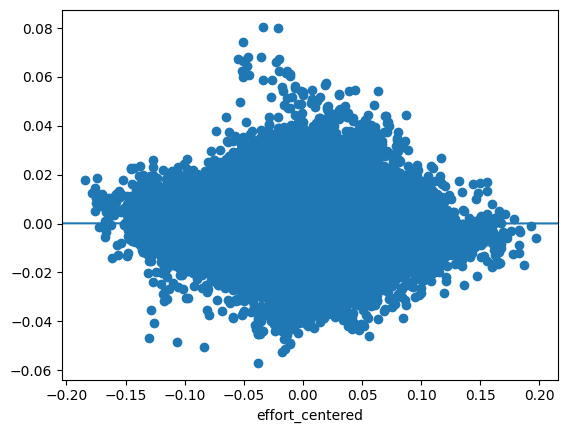

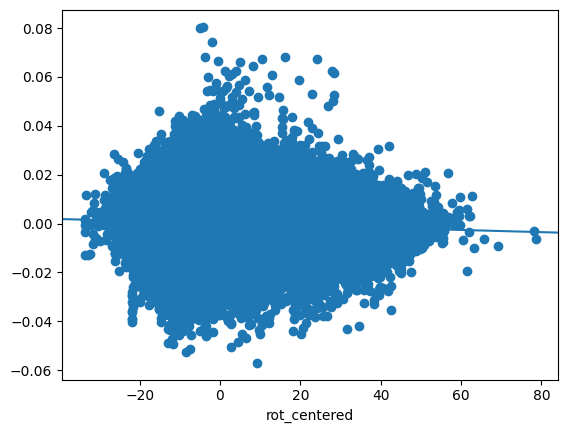

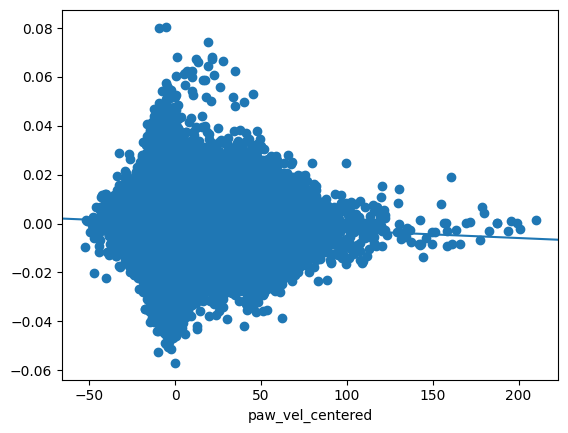

In [156]:
X_df = data.drop(columns=['df_centered'])
X = X_df.to_numpy()
y = data['df_centered'].to_numpy()

simple = simple_reg_for_each_parameter(X_df, y)



In [159]:
pd.DataFrame(simple).head()

,x_pos_centered,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
0,0.000047,0.000047,0.000047,4.711505e-05,4.750269e-05
1,-0.001509,-0.000636,-0.000113,-4.481098e-05,-2.997781e-05
2,0.008623,0.008656,0.008704,8.688340e-03,8.684493e-03
3,-50.115163,-38.895956,-0.166160,-2.235713e+01,-2.486293e+01
4,0.000000,0.000000,0.868031,1.644903e-110,3.835792e-136


In [172]:
def multiple_linreg(X, y):
    n_samples, n_features = X.shape
    rse = k_fold_cross_val(X, y, n_samples, n_features)
    weight, bias = linear_regression_gradient_descent(X, y)
    y_pred = numpy.dot(X, weight) + bias
    r2 = calculate_R2(y, y_pred)
    f = calculate_F(y, y_pred, n_features, n_samples)
    plt.figure()
    plt.scatter(y_pred, y-y_pred)
    return rse, r2, f

0.020784210305548112 566.2884319737044
0.008614470370658725


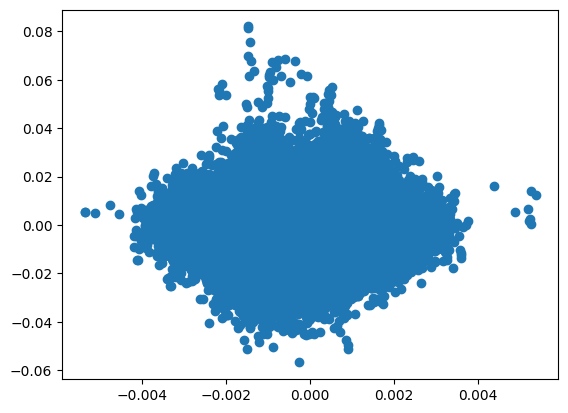

In [171]:
rse, r2, f = multiple_linreg(X_df.to_numpy(), y)
print(rse)

In [173]:
print(rse, r2, f)

0.008614470370658725 0.020784210305548112 566.2884319737044
